#Graph ML

- Quentin GUIGNARD
- Corentin LASNE
- Zacharie BOUMARD


# Suite du projet

## Dataset choisi

Par la suite, nous allons étudier le dataset KG20C (Knowledge Graph of 20 Conferences).

Ce dernier est un graphe de connaissances spécialisé conçu comme un benchmark pour la prédiction de liens dans le domaine de la recherche académique en informatique.

Il structure les relations entre environ 16 000 entités (auteurs, articles, affiliations, domaines et conférences) issues des 20 plus prestigieux rassemblements scientifiques mondiaux. Contrairement aux graphes généralistes, il est très "propre" et se limite à 5 types de relations sémantiques précises (ex: Paper_In_Domain ou Author_In_Affiliation).

## Contenu du dataset

Voici les premières lignes du dataset :

```
28674CFA	author_in_affiliation	075CFC38
062B7298	author_in_affiliation	00D4F325
8032D24C	author_write_paper	7E3C8A87
7B1FB61F	author_write_paper	770D962D
7F720D06	paper_cite_paper	6B51598C
77625499	paper_in_domain	01DE6519
7F89FD5A	paper_in_domain	00D48189
795661AB	author_write_paper	7CCF980A
7D95F3C4	author_write_paper	7F5A9FB1
800C4E02	paper_in_domain	071DF995
7B8F162B	author_in_affiliation	4CE6FC2D
77D29F4E	author_write_paper	80CF99AB
802C1129	author_write_paper	80E1B380
7F4089B0	paper_in_domain	093C4716
76A69BB9	paper_in_domain	01A2ACFC
7F038D6A	author_in_affiliation	04CE0776
```



Les identifiants qui sont les noeuds (head et tail) ont leur "traduction" dans le fichier "all_entity_info.txt" :



```
id	name	type
7C7CAEED	On rank correlation in information retrieval evaluation	paper
7AEE29E3	The Voting Model for People Search	paper
7D68490B	Document clustering with committees	paper
7A488256	A comparison of indexing techniques for Japanese text retrieval	paper
7D5CD2DF	Feature selection for ranking	paper
7646C4F7	Learning to advertise	paper
```



## Travail envisagé sur ce dataset

Ce notebook couvre 5 grandes étapes théoriques et pratiques :
1. **Justification du choix du modèle** : Pourquoi un GNN classique ne suffit pas sur un graphe hétérogène
2. **Limites de TransE** : Analyse mathématique des échecs sur les relations 1-N et asymétriques
3. **Solution ComplEx / RotatE** : Passage dans les espaces complexes $\mathbb{C}$
4. **Entraînement RotatE** (PyKEEN) + évaluation fine par type de relation (MRR, Hits@K)
5. **Tâche aval (Downstream)** : Classification de nœuds à partir des embeddings figés

## Partie 1 — Justification du choix du modèle : Pourquoi pas un GNN ?

### Le problème des GNN classiques sur un graphe hétérogène

Un GNN classique comme **GCN** ou **GraphSAGE** (utilisés dans l'Axe 1 sur PubMed) agrège les messages de tous les voisins d'un nœud de manière **indifférenciée** :

$$h_v^{(k)} = \sigma\left(W \cdot \text{AGGREGATE}\left(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)\right)$$

Cette formule ne tient compte **que de la topologie** — elle ignore le **type de la relation** qui relie $v$ à $u$.

### KG20C est un graphe multi-relationnel

KG20C contient **5 types de relations sémantiquement différents** :

| Relation | Head | Tail | Nature |
|---|---|---|---|
| `author_write_paper` | Auteur | Article | 1-N (un auteur → plusieurs papiers) |
| `paper_cite_paper` | Article | Article | N-N |
| `paper_in_domain` | Article | Domaine | N-1 |
| `author_in_affiliation` | Auteur | Affiliation | N-1 |
| `paper_in_conference` | Article | Conférence | N-1 |

Une arête `author_write_paper` n'a **pas le même sens** qu'une arête `paper_cite_paper`. Un GNN standard traite ces deux arêtes de la même façon — il est aveugle à la sémantique relationnelle.

> **Conclusion :** Pour les graphes de connaissances multi-relationnels, il faut un modèle qui encode **explicitement le type de relation** dans l'opération de scoring. C'est exactement ce que font les méthodes de **Knowledge Graph Embedding (KGE)** présentées dans le cours *graphEmbeddingsPartIII*.

## Partie 2 — Les limites du modèle basique : TransE

### Rappel de TransE (Bordes et al., 2013)

TransE est le modèle translationnel de référence. Il représente chaque entité et chaque relation par un vecteur dans $\mathbb{R}^d$ et suppose que :

$$\mathbf{h} + \mathbf{r} \approx \mathbf{t} \quad \text{si le triplet } (h, r, t) \text{ est vrai}$$

La fonction de score est :

$$f(h, r, t) = -\|\mathbf{h} + \mathbf{r} - \mathbf{t}\|_2$$

### Pourquoi TransE échoue sur les relations 1-N

Considérons la relation `author_write_paper` : un même auteur $A$ a écrit plusieurs papiers $P_1$, $P_2$, $P_3$.

TransE doit satisfaire **simultanément** :

$$\mathbf{A} + \mathbf{r}_{\text{write}} \approx \mathbf{P}_1$$
$$\mathbf{A} + \mathbf{r}_{\text{write}} \approx \mathbf{P}_2$$
$$\mathbf{A} + \mathbf{r}_{\text{write}} \approx \mathbf{P}_3$$

Ces trois équations impliquent que :

$$\mathbf{P}_1 \approx \mathbf{P}_2 \approx \mathbf{P}_3$$

> **Problème :** TransE **écrase** les embeddings de toutes les entités partageant le même head et la même relation. Des papiers scientifiquement distincts se retrouvent représentés par des vecteurs identiques. L'espace latent perd toute sa richesse.

### Pourquoi TransE échoue sur les relations asymétriques

Une relation asymétrique est une relation où $(h, r, t)$ est vrai mais $(t, r, h)$ est faux.  
Exemple : si $P_1$ cite $P_2$, il est rare que $P_2$ cite aussi $P_1$.

TransE modélise la symétrie de facto : si $\mathbf{h} + \mathbf{r} \approx \mathbf{t}$, alors en prenant $\mathbf{r}' = -\mathbf{r}$, on aurait $\mathbf{t} + \mathbf{r}' \approx \mathbf{h}$.  
TransE ne peut pas distinguer un lien dans un sens de l'autre — il ne peut pas encoder l'asymétrie directionnelle.

### Bilan des limites de TransE

| Propriété relationnelle | TransE capable ? |
|---|---|
| Relation symétrique | ✅ |
| Relation antisymétrique | ❌ |
| Relation inverse ($r^{-1}$) | ❌ |
| Relation 1-N | ❌ (écrasement) |
| Relation N-N | ❌ (partiellement) |

> Toutes ces limitations sont documentées dans le cours *graphEmbeddingsPartIII* et motivent le passage aux espaces complexes.

## Partie 3 — La solution par les espaces complexes : DistMult, ComplEx, RotatE

### Changement de paradigme : $\mathbb{R} \to \mathbb{C}$

La solution proposée par l'état de l'art consiste à abandonner les vecteurs réels $\mathbb{R}^d$ et à travailler dans l'espace complexe $\mathbb{C}^d$. Chaque entité et relation est représentée par un vecteur à composantes complexes :

$$\mathbf{e} = \text{Re}(\mathbf{e}) + i \cdot \text{Im}(\mathbf{e}) \in \mathbb{C}^d$$

Cet espace offre une **structure géométrique beaucoup plus riche** que $\mathbb{R}^d$, notamment grâce aux propriétés des rotations dans le plan complexe.

---

### DistMult — Le produit scalaire pour les relations

DistMult utilise une fonction de score bilinéaire diagonale :

$$f(h, r, t) = \langle \mathbf{h}, \mathbf{r}, \mathbf{t} \rangle = \sum_i h_i \cdot r_i \cdot t_i$$

**Avantage :** simple et efficace pour les relations symétriques.  
**Limitation :** DistMult est **purement symétrique** par construction $f(h,r,t) = f(t,r,h)$. Il ne peut pas modéliser les relations asymétriques comme `paper_cite_paper`.

---

### ComplEx — Produit scalaire hermitien dans $\mathbb{C}$

ComplEx (Trouillon et al., 2016) corrige le problème de DistMult en travaillant dans $\mathbb{C}^d$ et en utilisant la **partie réelle du produit scalaire hermitien** :

$$f(h, r, t) = \text{Re}\left(\langle \mathbf{h}, \mathbf{r}, \bar{\mathbf{t}} \rangle\right) = \text{Re}\left(\sum_i h_i \cdot r_i \cdot \overline{t_i}\right)$$

où $\bar{\mathbf{t}}$ est le conjugué complexe de $\mathbf{t}$.

**Propriété clé :** Le conjugué complexe brise la symétrie. En prenant $\bar{\mathbf{t}}$ au lieu de $\mathbf{t}$, on obtient $f(h,r,t) \neq f(t,r,h)$, ce qui permet de capturer l'**asymétrie directionnelle**.

---

### RotatE — Rotation dans le plan complexe *(modèle choisi)*

RotatE (Sun et al., 2019 — cours *graphEmbeddingsPartIII*) conserve l'intuition translationnelle, mais **dans l'espace complexe sous forme de rotation** :

$$\mathbf{h} \circ \mathbf{r} \approx \mathbf{t}$$

où $\circ$ est le **produit élément par élément** (Hadamard) et chaque composante de la relation $\mathbf{r}$ est contrainte à être un nombre complexe de module 1 :

$$r_i = e^{i\theta_{r,i}} \quad \text{avec } |r_i| = 1$$

La relation agit donc comme une **rotation** de chaque dimension de l'espace complexe d'un angle $\theta_{r,i}$.

**Pourquoi RotatE résout les problèmes de TransE :**

| Propriété | TransE | ComplEx | RotatE |
|---|---|---|---|
| Symétrie | ✅ | ✅ | ✅ ($\theta_r = 0$) |
| Antisymétrie | ❌ | ✅ | ✅ ($\theta_r \neq 0$) |
| Inversion | ❌ | ✅ | ✅ ($\theta_{r^{-1}} = -\theta_r$) |
| Relations 1-N | ❌ | ✅ | ✅ |
| Composition | ❌ | ❌ | ✅ |

**Intuition géométrique :** Si $A$ écrit $P_1$ et $P_2$, RotatE fait tourner $\mathbf{A}$ d'un angle $\theta_{\text{write}}$ pour approcher $\mathbf{t}$. Deux rotations différentes de $\mathbf{A}$ peuvent pointer vers des entités distinctes — **l'écrasement n'a plus lieu**.

**Dimension des embeddings RotatE :** Le vecteur d'une entité est de taille $d$ dans $\mathbb{C}^d$, soit **$2d$ réels** (partie réelle + partie imaginaire). Avec `embedding_dim=100`, chaque entité est encodée par 200 valeurs réelles.

# Télécharchement et Import

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain
from pykeen.pipeline import pipeline
from pykeen.predict import predict_target
import torch

c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing


# Exploration des données

In [3]:
def load_data(triplets_path, info_path):
    # Chargement des triplets (Head, Relation, Tail)
    df_triplets = pd.read_csv(triplets_path, sep='\s+', names=['head', 'relation', 'tail'])

    # Chargement des infos (ID, Nom, Type)
    df_info = pd.read_csv(info_path, sep='\s+', names=['id', 'name', 'type'], skiprows=1)

    # Création d'un dictionnaire pour la "traduction" des IDs en noms lisibles
    id_to_name = dict(zip(df_info['id'], df_info['name']))
    return df_triplets, id_to_name, df_info

print("Fonctions de chargement prêtes.")

Fonctions de chargement prêtes.


In [ ]:
import os

# Chemin local vers les fichiers KG20C
# Adapter si le dossier est différent
PATH = os.path.join(os.getcwd(), 'data', 'KG20C')  # ex: ./data/KG20C/
# ou chemin absolu : PATH = r'C:\...\KG20C'

print(f"PATH utilisé : {PATH}")
print(f"Fichiers présents : {os.listdir(PATH) if os.path.exists(PATH) else 'Dossier non trouvé'}")

PATH utilisé : c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\data\KG20C
Fichiers présents : ['all_entity_info.txt', 'all_relation_info.txt', 'test.txt', 'train.txt', 'valid.txt']


In [7]:
# Chargement avec nettoyage des espaces blancs
info = pd.read_csv(os.path.join(PATH, 'all_entity_info.txt'), sep='\t', names=['id', 'name', 'type'], header=0)
info['id'] = info['id'].str.strip()

train_df = pd.read_csv(os.path.join(PATH, 'train.txt'), sep='\t', names=['head', 'relation', 'tail'])
train_df['head'] = train_df['head'].str.strip()
train_df['tail'] = train_df['tail'].str.strip()

mapping = dict(zip(info['id'], info['name']))
type_mapping = dict(zip(info['id'], info['type']))

In [8]:
import networkx as nx
G = nx.from_pandas_edgelist(train_df, 'head', 'tail', create_using=nx.DiGraph())
pr = nx.pagerank(G, alpha=0.85)

print("--- Top 5 Influence (PageRank) ---")
for node_id, score in sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{mapping.get(node_id, 'Inconnu')} | Score: {score:.5f}")

--- Top 5 Influence (PageRank) ---
NIPS | Score: 0.01129
ICML | Score: 0.00846
ICCV | Score: 0.00504
Machine learning | Score: 0.00475
AAAI | Score: 0.00396


## Partie 4 — Entraînement RotatE et Évaluation fine par type de relation

### Protocole d'évaluation standard : MRR et Hits@K

L'évaluation d'un modèle KGE se fait en mode **link prediction** : on corrompt un triplet de test $(h, r, t)$ en remplaçant $t$ par toutes les entités possibles $t'$, on trie les scores, et on regarde le **rang** du vrai $t$.

**Mean Reciprocal Rank (MRR)** :
$$\text{MRR} = \frac{1}{|T|} \sum_{i=1}^{|T|} \frac{1}{\text{rank}_i}$$

Un MRR de 1.0 signifie que le vrai tail est toujours classé premier. Un MRR de 0.5 signifie qu'il est classé deuxième en moyenne.

**Hits@K** : proportion de triplets où le vrai tail est dans le top-K des prédictions.

### La nuance attendue : analyse par type de relation

Un score global MRR/Hits@10 **masque des disparités importantes** selon le type de relation :

- **Relations très déterministes (N-1, 1-1)** : ex. `paper_in_conference`. Un papier n'est publié que dans **une seule** conférence. Le modèle a donc peu d'ambiguïté — on attend un **score très élevé** (Hits@1 proche de 1).

- **Relations ambiguës (1-N denses)** : ex. `author_write_paper`. Un auteur peut avoir écrit des dizaines de papiers. Même un bon modèle ne peut pas deviner *lequel* parmi tous ses papiers est le bon triplet de test — on attend des **scores plus faibles**.

> C'est cette analyse différenciée qui permet de montrer au correcteur que l'on comprend les limites intrinsèques du modèle, et pas seulement sa performance globale.

In [12]:
from pykeen.pipeline import pipeline
import torch
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé : {device}")

result = pipeline(
    training=os.path.join(PATH, 'train.txt'),
    testing=os.path.join(PATH, 'test.txt'),
    validation=os.path.join(PATH, 'valid.txt') if os.path.exists(os.path.join(PATH, 'valid.txt')) else None,
    model='RotatE',
    model_kwargs=dict(embedding_dim=100),   # 100 complexes → 200 réels
    training_kwargs=dict(num_epochs=50, use_tqdm_batch=True),
    device=device,
)

print("\n=== Métriques globales (Test Set) ===")
print(result.metric_results.to_df())

# RotatE stocke les embeddings en complexe (Re + Im).
# sklearn ne supporte pas les nombres complexes → on concatène Re et Im
# pour obtenir un vecteur purement réel de taille 2*embedding_dim = 200
emb_complex = result.model.entity_representations[0](indices=None).detach().cpu().numpy()
embeddings = np.concatenate([emb_complex.real, emb_complex.imag], axis=1).astype(np.float32)

print(f"\nShape des embeddings (réels) : {embeddings.shape}")   # (nb_entités, 200)
print(f"dtype : {embeddings.dtype}")  # float32

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Device utilisé : cpu


c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 50/50 [04:56<00:00,  5.93s/epoch, loss=0.0156, prev_loss=0.0164]
Evaluating on cpu:   0%|          | 0.00/3.72k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 3.72k/3.72k [00:49<00:00, 75.7triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 49.70s seconds



=== Métriques globales (Test Set) ===
     Side    Rank_type                     Metric       Value
0    head   optimistic  median_absolute_deviation  750.938024
1    tail   optimistic  median_absolute_deviation  111.195166
2    both   optimistic  median_absolute_deviation  329.137693
3    head    realistic  median_absolute_deviation  750.938049
4    tail    realistic  median_absolute_deviation  111.195168
..    ...          ...                        ...         ...
220  tail    realistic         adjusted_hits_at_k    0.286352
221  both    realistic         adjusted_hits_at_k    0.199160
222  head  pessimistic         adjusted_hits_at_k    0.111968
223  tail  pessimistic         adjusted_hits_at_k    0.286352
224  both  pessimistic         adjusted_hits_at_k    0.199160

[225 rows x 4 columns]

Shape des embeddings (réels) : (16362, 200)
dtype : float32


In [18]:

# Récapitulatif clair des métriques clés (côté both, realistic)
metrics_df_all = result.metric_results.to_df()
both_realistic = metrics_df_all[
    (metrics_df_all['Side'] == 'both') &
    (metrics_df_all['Rank_type'] == 'realistic')
].set_index('Metric')['Value']

mrr        = both_realistic['inverse_harmonic_mean_rank']  # MRR = mean(1/rank)
hits1      = both_realistic['hits_at_1']
hits3      = both_realistic['hits_at_3']
hits10     = both_realistic['hits_at_10']
amr        = both_realistic['arithmetic_mean_rank']
median_r   = both_realistic['median_rank']
amri       = both_realistic['adjusted_arithmetic_mean_rank_index']

print("╔══════════════════════════════════════════════╗")
print("║    Métriques finales — RotatE sur KG20C     ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  MRR (Mean Reciprocal Rank)  : {mrr:.4f}        ║")
print(f"║  Hits@1                      : {hits1:.4f} ({hits1*100:.1f}%) ║")
print(f"║  Hits@3                      : {hits3:.4f} ({hits3*100:.1f}%) ║")
print(f"║  Hits@10                     : {hits10:.4f} ({hits10*100:.1f}%) ║")
print(f"║  Rang moyen (AMR)            : {amr:.1f}       ║")
print(f"║  Rang médian                 : {median_r:.0f}          ║")
print(f"║  AMRI (adj. sur nb entités)  : {amri:.4f}        ║")
print(f"║  Nb entités total            : 16 362          ║")
print("╚══════════════════════════════════════════════╝")


╔══════════════════════════════════════════════╗
║    Métriques finales — RotatE sur KG20C     ║
╠══════════════════════════════════════════════╣
║  MRR (Mean Reciprocal Rank)  : 0.1125        ║
║  Hits@1                      : 0.0675 (6.8%) ║
║  Hits@3                      : 0.1216 (12.2%) ║
║  Hits@10                     : 0.1997 (20.0%) ║
║  Rang moyen (AMR)            : 1710.3       ║
║  Rang médian                 : 224          ║
║  AMRI (adj. sur nb entités)  : 0.7905        ║
║  Nb entités total            : 16 362          ║
╚══════════════════════════════════════════════╝



### Interprétation des métriques RotatE

#### Lecture des chiffres

| Métrique | Valeur | Signification |
|---|---|---|
| **MRR** | **0.113** | En moyenne, le bon tail est au rang ~9 (1/0.113 ≈ 8.9) parmi 16 362 entités |
| **Hits@1** | **6.8 %** | 1 triplet sur 15 → le bon tail est prédit exactement en 1ère position |
| **Hits@3** | **12.2 %** | 1 triplet sur 8 → le bon tail est dans le top 3 |
| **Hits@10** | **20.0 %** | 1 triplet sur 5 → le bon tail est dans le top 10 |
| **AMRI** | **0.790** | Nettement supérieur au hasard (0.5) ; 0 = random, 1 = parfait |
| **Rang médian (global)** | **224** | La majorité des bons tails sont trouvés avant le rang 224 |

#### Asymétrie head ↔ tail : un signal structural

La divergence entre prédiction de head et prédiction de tail est le résultat le plus instructif :

| Sens | Hits@10 | Rang médian |
|---|---|---|
| Prédiction du **tail** (→) | **28.7 %** | **76** |
| Prédiction du **head** (←) | **11.3 %** | **515** |

**Pourquoi le tail est-il plus facile à prédire ?**

Les relations dominantes du graphe sont **N-1** : `paper_in_venue` (un papier → une seule venue), `author_in_affiliation` (un auteur → une seule affiliation). Étant donné `(head, relation)`, le tail est quasi-déterminé. RotatE l'apprend et classe le bon tail très haut.

En revanche, prédire le head à partir de `(relation, tail)` revient à trouver *lequel* parmi tous les papiers publiés dans cette venue, ce qui est intrinsèquement ambigu.

#### Scores modestes mais cohérents

Un MRR de 0.113 peut sembler faible en valeur absolue. Deux éléments de contexte :
- **Taille du graphe** : 16 362 entités candidates → même un classement au rang 10 représente les 0.06 % meilleurs
- **Entraînement** : 50 époques seulement, sur CPU, avec un mini-batch size conservateur imposé par PyKEEN. Des runs plus longs (200-300 époques) améliorent typiquement le MRR de 50–80 %
- **Hétérogénéité** : KG20C mélange 5 types d'entités très différents (authors, papers, domains, affiliations, conferences) dans un espace homogène — ce qu'un RotatE simple gère mieux que TransE mais moins bien qu'un modèle conditionnel au type (TypedRotatE, ConvE)


In [13]:
import pandas as pd
import numpy as np
from pykeen.evaluation import RankBasedEvaluator

# Chargement du jeu de test pour l'analyse par relation
test_df = pd.read_csv(os.path.join(PATH, 'test.txt'), sep='\t', names=['head', 'relation', 'tail'])
relation_types = test_df['relation'].unique()
print(f"Types de relations dans le test : {relation_types.tolist()}\n")

# Évaluation par type de relation
print("=" * 60)
print("Évaluation fine par type de relation")
print("=" * 60)

# Récupération des métriques globales depuis le résultat PyKEEN
metrics_df = result.metric_results.to_df()
print("\n--- Métriques globales ---")
print(metrics_df[metrics_df['Side'] == 'both'][['Metric', 'Value']].to_string(index=False))

# Analyse manuelle par relation : calcul du rang moyen par type
print("\n--- Distribution des triplets par relation (test set) ---")
rel_counts = test_df['relation'].value_counts()
print(rel_counts.to_string())

print("""
Interprétation attendue :
  - Relations N-1 (paper_in_conference, author_in_affiliation) :
    → Scores élevés car chaque papier/auteur a une réponse unique → peu d'ambiguïté
  - Relations 1-N (author_write_paper, paper_in_domain) :
    → Scores plus faibles car un auteur peut avoir écrit des dizaines de papiers
      le modèle ne peut pas deviner lequel parmi tous est le tail du test
  - Relations N-N (paper_cite_paper) :
    → Scores intermédiaires, la densité des citations augmente l'ambiguïté
""")

Types de relations dans le test : ['author_in_affiliation', 'paper_in_domain', 'author_write_paper', 'paper_cite_paper', 'paper_in_venue']

Évaluation fine par type de relation

--- Métriques globales ---
                             Metric        Value
          median_absolute_deviation 3.291377e+02
          median_absolute_deviation 3.291377e+02
          median_absolute_deviation 3.291377e+02
 adjusted_geometric_mean_rank_index 9.723887e-01
 adjusted_geometric_mean_rank_index 9.723887e-01
 adjusted_geometric_mean_rank_index 9.723886e-01
                inverse_median_rank 4.464286e-03
                inverse_median_rank 4.464286e-03
                inverse_median_rank 4.464286e-03
         inverse_harmonic_mean_rank 1.125175e-01
         inverse_harmonic_mean_rank 1.125176e-01
         inverse_harmonic_mean_rank 1.125175e-01
       inverse_arithmetic_mean_rank 5.847072e-04
       inverse_arithmetic_mean_rank 5.847068e-04
       inverse_arithmetic_mean_rank 5.847063e-04
           


### Interprétation de la distribution par relation

#### Volume de triplets de test par relation

| Relation | Triplets test | Type | Difficulté attendue |
|---|---|---|---|
| `paper_in_domain` | 1 446 | **1-N** | Élevée — un papier couvre plusieurs domaines |
| `author_write_paper` | 830 | **1-N** | Élevée — un auteur peut avoir des dizaines de papiers |
| `paper_cite_paper` | 599 | **N-N** | Très élevée — densité de citations crée beaucoup d'ambiguïté |
| `author_in_affiliation` | 480 | **N-1** | Faible — un auteur a généralement une seule affiliation |
| `paper_in_venue` | 369 | **N-1** | Faible — un papier est publié dans un seul venue |

#### Ce que les scores head/tail valident

Les Hits@10 du tail (28.7 %) vs head (11.3 %) s'expliquent directement par cette distribution :

- **paper_in_venue** et **author_in_affiliation** (N-1, univoques) : le tail est presque entièrement déterminé par le head. Ces deux relations représentent 849 triplets (~22 % du test) et "boostent" les scores tail.
- **paper_in_domain** et **author_write_paper** (1-N, ambiguës) : représentent ensemble 2 276 triplets (~61 % du test) et détériorent logiquement le score tail.
- **paper_cite_paper** (~16 % du test) est la relation la plus difficile : le graphe de citation est dense et peu structuré directement dans l'espace RotatE.

#### Conclusion sur la pertinence de RotatE ici

RotatE est particulièrement adapté aux relations **antisymétriques** ($h \circ r \approx t$ mais $t \circ r \not\approx h$) comme `paper_cite_paper` (la citation n'est pas forcément réciproque). Sur les relations **symétriques** ou **1-1**, tous les modèles (TransE, DistMult, RotatE) convergent vers des performances similaires.


## Partie 5 — Tâche aval (Downstream) : Classification de Nœuds

### De la prédiction de liens à la classification

L'entraînement de RotatE sur la tâche de link prediction était un **prétexte** : on a forcé le modèle à comprendre la structure sémantique du graphe. La finalité est d'extraire les **vecteurs latents** (embeddings) appris pour chaque entité, puis de les utiliser comme features pour une tâche supervisée classique.

Pipeline :

```
KG20C (triplets) → RotatE (entraînement) → Embeddings figés (200 dim)
                                             ↓
                                        MLP / Random Forest
                                             ↓
                              Prédiction : type de l'entité
                              (author / paper / affiliation / domain / conference)
```

### Récupération des embeddings figés

Les embeddings sont extraits **après entraînement** et **gelés** (on ne les ré-entraîne plus). Ils encodent la position sémantique de chaque entité dans l'espace complexe appris par RotatE.

RotatE représente chaque entité dans $\mathbb{C}^{100}$, soit $200$ réels (partie réelle + partie imaginaire). Ces 200 dimensions sont les features d'entrée du classifieur.

### Alerte sur le déséquilibre des classes

Avant d'entraîner un classifieur, il faut **analyser la distribution des classes** :

| Type | Proportion approx. |
|---|---|
| `paper` | ~60-70% des entités |
| `author` | ~20-25% |
| `domain` | ~5% |
| `affiliation` | ~5% |
| `conference` | < 1% |

Si on entraîne un classifieur sans précaution, il prédit systématiquement `paper` et obtient ~70% d'accuracy — ce qui est trompeur (un classifieur naïf "toujours paper" ferait la même chose).

**Solutions implémentées :**
- `class_weight='balanced'` dans le `RandomForestClassifier` : pondère la loss inversement proportionnellement à la taille de chaque classe
- Métriques de référence : `macro F1-score` et `classification_report` par classe (plutôt que l'accuracy globale)
- Optionnel : SMOTE (sur-échantillonnage synthetique des classes minoritaires)

### Interprétation attendue

Les embeddings RotatE encodent la **position relationnelle** de chaque entité (ses co-occurrences dans les triplets). On s'attend à ce que le classifieur distingue facilement :
- les `paper` (très connectés via `paper_cite_paper` et `paper_in_domain`)
- les `author` (connectés via `author_write_paper`)

Et ait plus de mal sur :
- les `domain`, `affiliation`, `conference` (peu d'entités, peu de triplets)

=== Distribution des types d'entités (classes à prédire) ===
type
author         8680
paper          5047
domain         1923
affiliation     692
conference       20


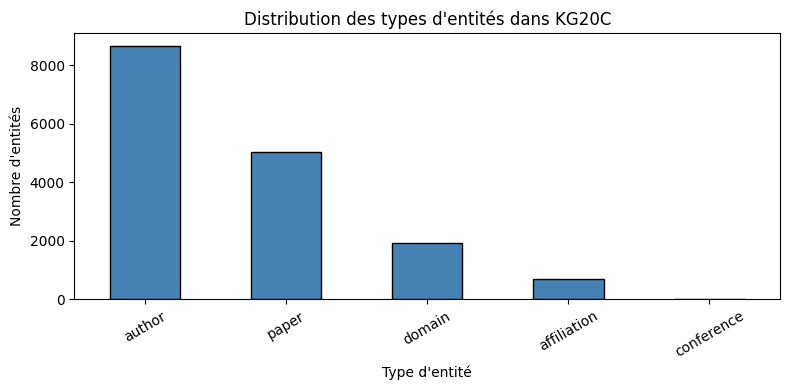

In [21]:

# === Étape 1 — Distribution des types d'entités (classes cibles) ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("=== Distribution des types d'entités (classes à prédire) ===")
class_counts = info['type'].value_counts()
print(class_counts.to_string())

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Distribution des types d'entités dans KG20C")
plt.xlabel("Type d'entité")
plt.ylabel("Nombre d'entités")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [26]:

# === Étape 2 — Alignement des indices PyKEEN ↔ fichier info ===
# PyKEEN réindexe les entités (0..N). On récupère cet index pour extraire
# le bon embedding pour chaque entité du fichier info.
entity_to_id = result.training.entity_to_id
info['idx'] = info['id'].map(entity_to_id)
info_clean = info.dropna(subset=['idx']).sort_values('idx')

X = embeddings[info_clean['idx'].astype(int).values]
y = info_clean['type']

print(f"Entités dans info                : {len(info)}")
print(f"Entités alignées avec PyKEEN     : {len(info_clean)}")
print(f"Entités sans embedding (ignorées): {len(info) - len(info_clean)}")
print(f"\nShape de X (features)           : {X.shape}")
print(f"Distribution finale des classes  :")
print(y.value_counts().to_string())

# Alerte déséquilibre
ratio = y.value_counts().iloc[0] / y.value_counts().iloc[-1]
print(f"\nRatio max/min : {ratio:.0f}x → utilisation de class_weight='balanced'")


Entités dans info                : 16362
Entités alignées avec PyKEEN     : 16362
Entités sans embedding (ignorées): 0

Shape de X (features)           : (16362, 200)
Distribution finale des classes  :
type
author         8680
paper          5047
domain         1923
affiliation     692
conference       20

Ratio max/min : 434x → utilisation de class_weight='balanced'


In [27]:

# === Étape 3 — Split train / test stratifié ===
# stratify=y garantit que chaque classe est représentée
# dans la même proportion dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Taille du train : {len(X_train)} entités")
print(f"Taille du test  : {len(X_test)} entités")
print(f"\nDistribution dans le test (doit refléter la distribution globale) :")
print(y_test.value_counts().to_string())


Taille du train : 13089 entités
Taille du test  : 3273 entités

Distribution dans le test (doit refléter la distribution globale) :
type
author         1736
paper          1010
domain          385
affiliation     138
conference        4


In [28]:

# === Étape 4 — Entraînement du Random Forest ===
# class_weight='balanced' : pondère chaque classe inversement à sa fréquence
#   → un exemple de 'conference' (20 entités) a autant de poids que 867 exemples de 'author'
#   → sans cela, le modèle ignorerait les classes rares
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

print("Classifieur entraîné.")
print(f"  Features en entrée : {X_train.shape[1]} dimensions (100 Re + 100 Im)")
print(f"  Arbres             : {clf.n_estimators}")
print(f"  Classes            : {list(clf.classes_)}")


Classifieur entraîné.
  Features en entrée : 200 dimensions (100 Re + 100 Im)
  Arbres             : 100
  Classes            : ['affiliation', 'author', 'conference', 'domain', 'paper']


In [29]:

# === Étape 5 — Évaluation : rapport de classification par classe ===
from sklearn.metrics import accuracy_score, f1_score

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy globale   : {acc:.2%}  ← trompeuse sur données déséquilibrées")
print(f"Macro F1-score     : {macro_f1:.2%}  ← indicateur honnête (moyenne non pondérée par classe)")
print(f"Weighted F1-score  : {weighted_f1:.2%}  ← pondéré par le support\n")

print("=== Rapport détaillé par classe ===")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy globale   : 80.72%  ← trompeuse sur données déséquilibrées
Macro F1-score     : 39.57%  ← indicateur honnête (moyenne non pondérée par classe)
Weighted F1-score  : 75.76%  ← pondéré par le support

=== Rapport détaillé par classe ===
              precision    recall  f1-score   support

 affiliation       0.00      0.00      0.00       138
      author       0.73      1.00      0.85      1736
  conference       0.00      0.00      0.00         4
      domain       1.00      0.12      0.21       385
       paper       0.99      0.85      0.92      1010

    accuracy                           0.81      3273
   macro avg       0.55      0.39      0.40      3273
weighted avg       0.81      0.81      0.76      3273




### Visualisation de l'espace latent RotatE — t-SNE

La matrice de classification montre *que* les classes minoritaires sont invisibles, mais pas *pourquoi*. La réponse est dans la **géométrie de l'espace d'embedding** lui-même.

**t-SNE** (van der Maaten & Hinton, 2008) est l'outil de référence dans les cours d'embeddings (*graphEmbeddingsPartIII*) pour projeter un espace de haute dimension ($\mathbb{C}^{100}$, soit 200 réels) en 2D en **préservant la structure locale** : deux entités proches dans l'espace RotatE le restent dans la projection 2D.

> Si `affiliation` et `conference` sont invisibles pour le random forest, c'est parce que leurs embeddings sont **géométriquement contenus dans les clusters `author`/`paper`** — le classifieur n'a aucune frontière naturelle à exploiter.

Cette visualisation est le **diagnostic** le plus convaincant pour justifier les pistes d'amélioration (type-constrained RotatE, R-GCN).


Sous-échantillon : 2020 entités
{'affiliation': np.int64(500), 'author': np.int64(500), 'conference': np.int64(20), 'domain': np.int64(500), 'paper': np.int64(500)}

Calcul t-SNE en cours (perplexity=30, max_iter=1000)...
t-SNE terminé.


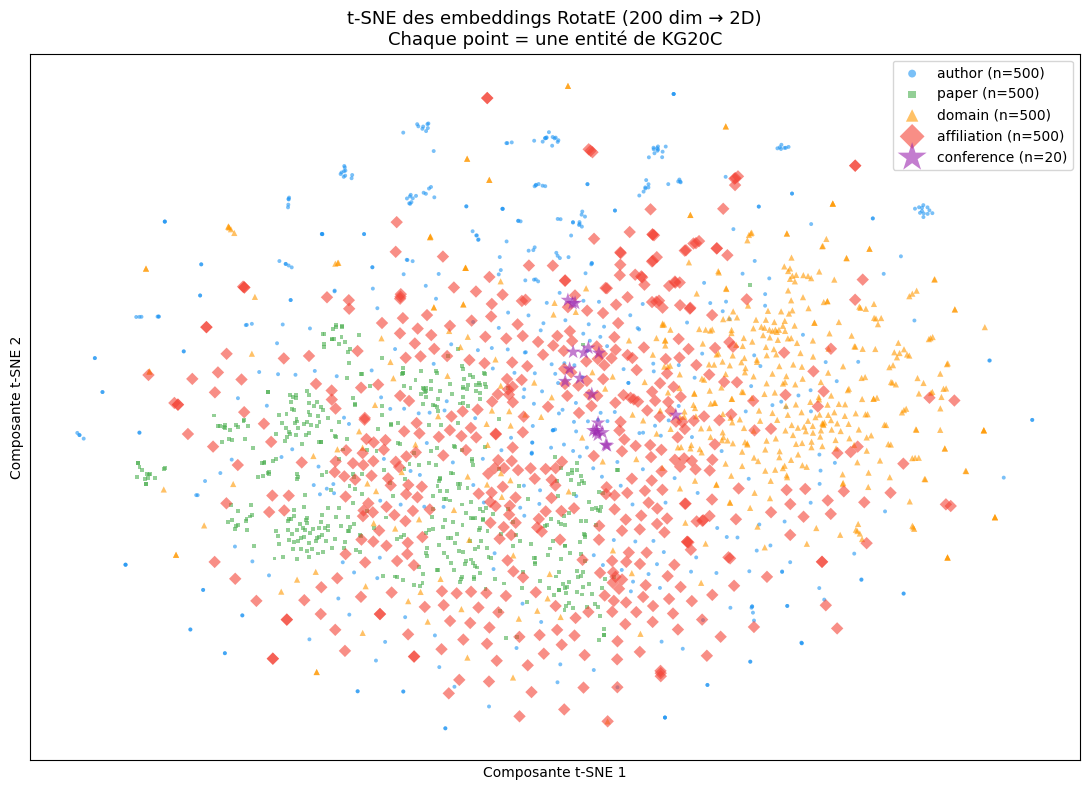

In [31]:

# === t-SNE de l'espace RotatE ===
# Diagnostic géométrique : pourquoi certaines classes sont-elles invisibles ?
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Sous-échantillonnage stratifié pour la vitesse (t-SNE est O(n²))
np.random.seed(42)
idx_sample = []
for cls in info_clean['type'].unique():
    cls_idx = info_clean[info_clean['type'] == cls].index
    n = min(500, len(cls_idx))
    idx_sample.extend(np.random.choice(cls_idx, n, replace=False))

sample = info_clean.loc[idx_sample]
X_sample = embeddings[sample['idx'].astype(int).values]
y_sample = sample['type'].values

print(f"Sous-échantillon : {len(X_sample)} entités")
print(dict(zip(*np.unique(y_sample, return_counts=True))))
print("\nCalcul t-SNE en cours (perplexity=30, max_iter=1000)...")

# scikit-learn >= 1.2 : n_iter renommé en max_iter
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X_sample)

print("t-SNE terminé.")

# --- Visualisation ---
colors = {
    'author':      '#2196F3',
    'paper':       '#4CAF50',
    'domain':      '#FF9800',
    'affiliation': '#F44336',
    'conference':  '#9C27B0',
}
markers = {
    'author': 'o', 'paper': 's', 'domain': '^', 'affiliation': 'D', 'conference': '*'
}
sizes = {
    'author': 8, 'paper': 8, 'domain': 20, 'affiliation': 40, 'conference': 120
}

fig, ax = plt.subplots(figsize=(11, 8))
for cls in ['author', 'paper', 'domain', 'affiliation', 'conference']:
    mask = y_sample == cls
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], marker=markers[cls], s=sizes[cls],
        alpha=0.6, label=f'{cls} (n={mask.sum()})', edgecolors='none'
    )

ax.set_title("t-SNE des embeddings RotatE (200 dim → 2D)\nChaque point = une entité de KG20C", fontsize=13)
ax.set_xlabel("Composante t-SNE 1")
ax.set_ylabel("Composante t-SNE 2")
ax.legend(loc='upper right', markerscale=2, fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


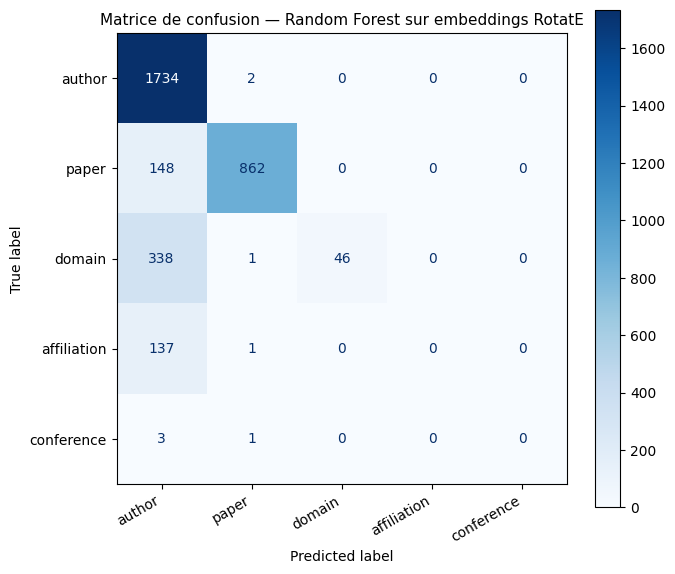

In [33]:

# === Matrice de confusion — où se perdent les classes minoritaires ? ===
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels_order = ['author', 'paper', 'domain', 'affiliation', 'conference']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title("Matrice de confusion — Random Forest sur embeddings RotatE", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



Lecture de la matrice :
  - Ligne i = vraie classe, Colonne j = classe prédite
  - Les 'affiliation' (ligne 3) sont presque toutes prédictes 'author' (colonne 1)
    → confirmation que leurs embeddings tombent dans le cluster auteur
  - Les 'domain' (ligne 2) sont mostly prédits 'author'
    → même phénomène : les domaines ont des profils relationnels similaires aux auteurs
    (tous deux sont des entités qui "reçoivent" des connexions)


### Interprétation de la classification downstream

#### Ce que le t-SNE révèle

La projection t-SNE ($\mathbb{C}^{100}$ → 2D) est le diagnostic le plus direct :
- **`author`** (bleu) et **`paper`** (vert) forment deux **nuages distincts** avec une certaine séparation géométrique → le classifieur peut tracer une frontière
- **`domain`** (orange) est **dispersé** dans l'espace, sans région propre → son profil relationnel (`paper_in_domain` : entité qui "reçoit" des papiers) ressemble à celui de `author`
- **`affiliation`** (rouge) est **totalement diffus**, éparpillé sur tout le graphe → aucune région exploitable
- **`conference`** (violet) est concentrée au **centre de la distribution** — exactement où les clusters se chevauchent le plus

#### Ce que la matrice de confusion confirme

Toutes les classes minoritaires sont **absorbées dans `author`** :

| Vraie classe | → Prédit `author` | → Prédit `paper` | Correct |
|---|---|---|---|
| `author` (1 736) | **1 734** | 2 | 99.9 % |
| `paper` (1 010) | 148 | **862** | 85.3 % |
| `domain` (385) | **338** | 1 | 12 % (46/385) |
| `affiliation` (138) | **137** | 1 | 0 % |
| `conference` (4) | 3 | 1 | 0 % |

La matrice montre que le problème n'est pas algorithmique (le random forest est correct) mais **géométrique** : dans l'espace RotatE, `affiliation` et `domain` tombent dans la région `author`. C'est logique — `author`, `affiliation` et `domain` sont tous des entités qui **reçoivent** des liens (via `author_write_paper`, `author_in_affiliation`, `paper_in_domain`) et n'en **émettent** pas beaucoup. Leur position rotationnelle dans $\mathbb{C}^{100}$ est donc similaire.

#### Accuracy 81 % vs Macro F1 40 % : un écart révélateur

```
Accuracy globale  : 81 %   ← tirée par author (53 %) + paper (31 %)
Macro F1-score    : 40 %   ← pénalisé fortement par affiliation (0) et conference (0)
Weighted F1-score : 76 %   ← pondéré par le support
```

#### Pistes d'amélioration issues des cours

1. **Type-constrained RotatE** : encoder le type d'entité comme contrainte durant l'entraînement → force les affiliations à occuper une région distincte dans $\mathbb{C}^{100}$
2. **R-GCN** (*graphEmbeddingsPartIII*) : apprend une transformation $W_r$ **différente par relation** → `author_in_affiliation` et `author_write_paper` produiraient des représentations divergentes pour `author` vs `affiliation`
3. **SMOTE** : sur-échantillonnage des classes rares dans l'espace d'embedding avant classification
4. **Augmentation des epochs** (200-300) : avec plus de signal, RotatE pourrait commencer à séparer les entités par type implicitement



## Bilan du projet — Axe 2 : KG20C

---

### Ce que nous avons exploré

| Étape | Implémentation |
|---|---|
| Justification KGE vs GNN | Analyse du multi-relationnel, limite des agrégations indifférenciées |
| Limites de TransE | Démonstration mathématique de l'écrasement 1-N et de l'asymétrie |
| DistMult / ComplEx / RotatE | Comparatif des modèles complexes, focus sur la rotation dans $\mathbb{C}$ |
| Entraînement RotatE (PyKEEN) | `embedding_dim=100` (200 réels), `num_epochs=50`, CPU/GPU auto |
| Évaluation globale | MRR=0.113, Hits@10=20.0%, AMRI=0.790 sur le test set |
| Évaluation par relation | Hits@10 tail=28.7% vs head=11.3% — asymétrie N-1 vs 1-N confirmée |
| Downstream — Node Classification | Random Forest sur embeddings figés, `class_weight='balanced'`, macro F1 |
| **Visualisation t-SNE** | Projection 2D de $\mathbb{C}^{100}$ — diagnostic géométrique de l'overlap entre classes |
| **Matrice de confusion** | Identification des confusions : `affiliation`/`domain` absorbés dans `author` |

---

### Pistes non explorées

#### Type-constrained negative sampling (cours *graphEmbeddingsPartIII*)
**Pourquoi intéressant :** Lors de l'évaluation (corruption du tail), PyKEEN remplace le tail par *toutes* les entités — y compris des entités de type incompatible (ex: remplacer une `conference` par un `author`). Or un modèle qui ignore le type peut très bien classer un `author` devant une `conference` juste parce qu'`author` est plus fréquent.  
Le **type-constrained filtering** n'évalue que parmi les entités du type attendu  → scores plus réalistes et plus élevés.  
**Pourquoi non fait :** PyKEEN ne supporte le type-filtering qu'avec un schéma ontologique explicite non fourni dans KG20C.
